# **User Analytics in the Telecommunication Industry**

## 4. **User Satisfaction Analysis**

This section combines customer engagement and network experience metrics to evaluate overall customer satisfaction. Engagement scores are derived from the customer engagement analysis, while experience scores are derived from the customer experience analysis. These scores are then combined to calculate a satisfaction score for each customer.

## 4.1 **Required Libraries**


In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Required libraries imported successfully.")

Required libraries imported successfully.


In [ ]:
# Define paths for the required project files

engagement_file = '../outputs/user_engagement_metrics.csv'
experience_file = '../outputs/user_experience_metrics.csv'

print("Project file paths defined successfully.")

Project file paths defined successfully.


In [ ]:
# Load the customer-level engagement and experience data

engagement_data = pd.read_csv(engagement_file)
experience_data = pd.read_csv(experience_file)

print("Engagement data loaded successfully.")
print("Engagement data shape:", engagement_data.shape)

print("\nExperience data loaded successfully.")
print("Experience data shape:", experience_data.shape)

Engagement data loaded successfully.
Engagement data shape: (106856, 5)

Experience data loaded successfully.
Experience data shape: (106856, 6)


In [ ]:
# Verify columns and customer IDs

print("Engagement columns:")
print(engagement_data.columns.tolist())

print("\nExperience columns:")
print(experience_data.columns.tolist())

print("\nEngagement customer IDs:", engagement_data['MSISDN/Number'].nunique())
print("Experience customer IDs:", experience_data['MSISDN/Number'].nunique())

Engagement columns:
['MSISDN/Number', 'xDR_Sessions', 'Total_Session_Duration_ms', 'Total_Traffic_Bytes', 'Engagement_Cluster']

Experience columns:
['MSISDN/Number', 'Average_TCP_Retransmission', 'Average_RTT', 'Handset_Type', 'Average_Throughput', 'Experience_Cluster']

Engagement customer IDs: 106856
Experience customer IDs: 106856


## 4.2 **Merge Engagement and Experience Data**

In [ ]:
# Merge engagement and experience data using customer ID

satisfaction_data = pd.merge(
    engagement_data,
    experience_data,
    on='MSISDN/Number',
    how='inner',
    suffixes=('_Engagement', '_Experience')
)

print("Engagement and experience data merged successfully.")
print("Combined data shape:", satisfaction_data.shape)
print("\nMissing values after merge:", satisfaction_data.isna().sum().sum())
print("Duplicate customer IDs:", satisfaction_data['MSISDN/Number'].duplicated().sum())

Engagement and experience data merged successfully.
Combined data shape: (106856, 10)

Missing values after merge: 0
Duplicate customer IDs: 0


## 4.3 **Engagement Score Calculation**

In [ ]:
# Calculate the engagement score as the Euclidean distance
# from the lower-engagement cluster

engagement_features = [
    'xDR_Sessions',
    'Total_Session_Duration_ms',
    'Total_Traffic_Bytes'
]

# Standardize engagement metrics so that all features are comparable
engagement_scaler = StandardScaler()

engagement_scaled = engagement_scaler.fit_transform(
    satisfaction_data[engagement_features]
)

# Lower-engagement cluster identified from Task 2
less_engaged_cluster = 1

# Calculate the centroid of the lower-engagement cluster
less_engaged_centroid = engagement_scaled[
    satisfaction_data['Engagement_Cluster'] == less_engaged_cluster
].mean(axis=0)

# Calculate Euclidean distance from the lower-engagement centroid
satisfaction_data['Engagement_Score'] = np.linalg.norm(
    engagement_scaled - less_engaged_centroid,
    axis=1
)

print("Engagement score calculated successfully.")
print("Less-engaged cluster:", less_engaged_cluster)
print(
    "Engagement score range:",
    round(satisfaction_data['Engagement_Score'].min(), 4),
    "to",
    round(satisfaction_data['Engagement_Score'].max(), 4)
)

print("\nEngagement score summary:")
print(satisfaction_data['Engagement_Score'].describe())

Engagement score calculated successfully.
Less-engaged cluster: 1
Engagement score range: 0.0362 to 32.0697

Engagement score summary:
count    106856.000000
mean          1.237768
std           1.394926
min           0.036211
25%           0.538321
50%           0.791669
75%           1.429589
max          32.069654
Name: Engagement_Score, dtype: float64


## 4.4 **Experience Score Calculation**

The experience score is calculated as the Euclidean distance of each customer from the identified weaker experience cluster using standardized network experience metrics.

The experience score is based on Average TCP Retransmission, Average RTT, and Average Throughput. A higher experience score indicates that the customer is farther from the weaker experience reference cluster in the standardized feature space.


In [ ]:
# Calculate the experience score as the Euclidean distance
# from the worst experience cluster

experience_features = [
    'Average_TCP_Retransmission',
    'Average_RTT',
    'Average_Throughput'
]

# Standardize experience metrics
experience_scaler = StandardScaler()

experience_scaled = experience_scaler.fit_transform(
    satisfaction_data[experience_features]
)

# Worst experience cluster identified from Task 3
worst_experience_cluster = 2

# Calculate centroid of the worst experience cluster
worst_experience_centroid = experience_scaled[
    satisfaction_data['Experience_Cluster'] == worst_experience_cluster
].mean(axis=0)

# Calculate Euclidean distance from the worst experience centroid
satisfaction_data['Experience_Score'] = np.linalg.norm(
    experience_scaled - worst_experience_centroid,
    axis=1
)

print("Experience score calculated successfully.")
print("Worst experience cluster:", worst_experience_cluster)

print(
    "Experience score range:",
    round(satisfaction_data['Experience_Score'].min(), 4),
    "to",
    round(satisfaction_data['Experience_Score'].max(), 4)
)

print("\nExperience score summary:")
print(satisfaction_data['Experience_Score'].describe())

Experience score calculated successfully.
Worst experience cluster: 2
Experience score range: 0.0683 to 5.3403

Experience score summary:
count    106856.000000
mean          1.964431
std           1.049229
min           0.068330
25%           1.377427
50%           2.133375
75%           2.548381
max           5.340345
Name: Experience_Score, dtype: float64


In [ ]:
# Calculate the overall satisfaction score
# as the average of engagement and experience scores

satisfaction_data['Satisfaction_Score'] = (
    satisfaction_data['Engagement_Score'] +
    satisfaction_data['Experience_Score']
) / 2

print("Satisfaction score calculated successfully.")

print("\nSatisfaction score summary:")
print(satisfaction_data['Satisfaction_Score'].describe())

Satisfaction score calculated successfully.

Satisfaction score summary:
count    106856.000000
mean          1.601100
std           0.871197
min           0.127244
25%           1.169054
50%           1.531538
75%           1.954544
max          16.814416
Name: Satisfaction_Score, dtype: float64


## 4.5 **Satisfaction Score Calculation**

The overall satisfaction score is calculated as the average of the engagement score and the experience score for each customer.

The satisfaction score combines the engagement and network experience scores into a single customer-level analytical measure. A higher score indicates greater distance from the lower-engagement and weaker-experience reference clusters used in this analysis.

## 4.6 **Top 10 Satisfied Customers**

The top 10 customers are identified based on their satisfaction scores. Customers with the highest satisfaction scores are selected for further analysis.

In [ ]:
# Identify the top 10 satisfied customers

top_10_satisfied = (
    satisfaction_data[
        [
            'MSISDN/Number',
            'Engagement_Score',
            'Experience_Score',
            'Satisfaction_Score'
        ]
    ]
    .sort_values(
        by='Satisfaction_Score',
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 satisfied customers:")
display(top_10_satisfied)

Top 10 satisfied customers:


,MSISDN/Number,Engagement_Score,Experience_Score,Satisfaction_Score
0,3.362632e+10,32.069654,1.559178,16.814416
1,3.361489e+10,31.582199,1.930958,16.756578
2,3.362578e+10,30.976909,2.136957,16.556933
3,3.365973e+10,30.510927,2.327476,16.419202
4,3.367588e+10,28.990680,1.935548,15.463114
5,3.376054e+10,29.241245,0.562223,14.901734
6,3.366471e+10,23.243374,2.426499,12.834937
7,3.365936e+10,22.413832,2.748812,12.581322
8,3.366716e+10,22.261835,2.837461,12.549648
9,3.376041e+10,23.021133,2.070503,12.545818


## 4.7 **Satisfaction Score Regression Model**

A Linear Regression model is used to examine the relationship between the engagement score, experience score, and the overall satisfaction score.

The satisfaction score is calculated from the engagement and experience scores, so the regression is used to demonstrate this relationship rather than to represent an independent prediction target.

In [ ]:
# Prepare data for satisfaction score regression

regression_features = [
    'Engagement_Score',
    'Experience_Score'
]

X = satisfaction_data[regression_features]
y = satisfaction_data['Satisfaction_Score']

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create and train the Linear Regression model
regression_model = LinearRegression()

regression_model.fit(X_train, y_train)

# Predict satisfaction scores
y_pred = regression_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Satisfaction regression model trained successfully.")
print("Mean Squared Error:", round(mse, 6))
print("R-squared:", round(r2, 6))

Satisfaction regression model trained successfully.
Mean Squared Error: 0.0
R-squared: 1.0


## 4.8 **Actual vs Predicted Satisfaction Scores**

The actual and predicted satisfaction scores are compared using a scatter plot to visualize the performance of the linear regression model.

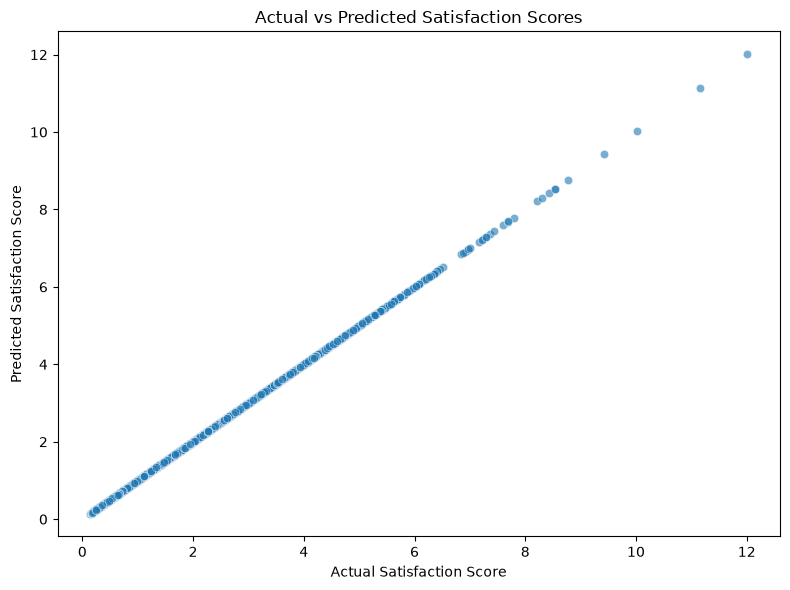

In [ ]:
# Visualize actual vs predicted satisfaction scores

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.6
)

plt.xlabel('Actual Satisfaction Score')
plt.ylabel('Predicted Satisfaction Score')
plt.title('Actual vs Predicted Satisfaction Scores')

plt.tight_layout()
plt.show()

### Key Insights

- The actual and predicted satisfaction scores show an almost perfect alignment along the diagonal, indicating that the linear regression model reproduces the calculated satisfaction scores accurately.

- The model performance is consistent with the evaluation results, with **Mean Squared Error (MSE) = 0.0** and **R² = 1.0**.

- The close alignment occurs because the satisfaction score is mathematically derived from the engagement and experience scores, which are also used as predictors in the regression model.

- Therefore, the regression result demonstrates the deterministic relationship between the input scores and the calculated satisfaction score rather than independent predictive performance on an externally observed satisfaction measure.

- K = 2 is selected to segment customers into two satisfaction-related groups based on their standardized engagement and experience scores.

## 4.9 **K-Means Clustering of Satisfaction Scores**

K-Means clustering with K = 2 is applied to the engagement and experience scores to segment customers into two satisfaction-related groups.



In [ ]:
# Prepare engagement and experience scores for K-Means clustering

satisfaction_features = satisfaction_data[
    ['Engagement_Score', 'Experience_Score']
].copy()

scaler_satisfaction = StandardScaler()

satisfaction_scaled = scaler_satisfaction.fit_transform(
    satisfaction_features
)

print("Satisfaction features standardized successfully.")
print("Scaled data shape:", satisfaction_scaled.shape)

Satisfaction features standardized successfully.
Scaled data shape: (106856, 2)


In [ ]:
# Apply K-Means clustering with K = 2

satisfaction_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

satisfaction_data['Satisfaction_Cluster'] = satisfaction_kmeans.fit_predict(
    satisfaction_scaled
)

print("K-Means clustering completed successfully.")
print("\nCluster counts:")
print(satisfaction_data['Satisfaction_Cluster'].value_counts().sort_index())

K-Means clustering completed successfully.

Cluster counts:
Satisfaction_Cluster
0    37238
1    69618
Name: count, dtype: int64


## 4.10 **Cluster-wise Satisfaction and Experience Analysis**

The two satisfaction clusters are compared using the average satisfaction score and experience score to understand the characteristics of each customer group.

In [ ]:
# Calculate cluster-wise average satisfaction and experience scores

cluster_summary = (
    satisfaction_data
    .groupby('Satisfaction_Cluster')
    .agg(
        Customer_Count=('MSISDN/Number', 'count'),
        Average_Satisfaction_Score=('Satisfaction_Score', 'mean'),
        Average_Experience_Score=('Experience_Score', 'mean')
    )
    .reset_index()
)

cluster_summary[
    ['Average_Satisfaction_Score', 'Average_Experience_Score']
] = cluster_summary[
    ['Average_Satisfaction_Score', 'Average_Experience_Score']
].round(4)

print("Cluster-wise satisfaction summary:")
display(cluster_summary)

Cluster-wise satisfaction summary:


,Satisfaction_Cluster,Customer_Count,Average_Satisfaction_Score,Average_Experience_Score
0,0,37238,1.3549,0.8731
1,1,69618,1.7328,2.5482


### Key Insights

- **Cluster 0** contains **37,238 customers**, with an average satisfaction score of **1.3549** and an average experience score of **0.8731**.

- **Cluster 1** contains **69,618 customers**, with an average satisfaction score of **1.7328** and an average experience score of **2.5482**.

- Cluster 1 has a higher average satisfaction score than Cluster 0, along with a higher average experience score.

- The difference between the two clusters indicates that customer satisfaction varies across groups based on the combined engagement and experience score framework used in this analysis.

- The cluster labels are numerical identifiers assigned by K-Means; therefore, the observed score differences should be interpreted using the cluster-level metrics rather than the cluster number itself.

## 4.11 **Final Customer Satisfaction Dataset**

The final customer-level dataset combines engagement metrics, experience metrics, engagement and experience scores, the overall satisfaction score, and the satisfaction cluster assigned using K-Means.

In [ ]:
# Create the final customer-level satisfaction dataset

final_satisfaction_data = satisfaction_data[
    [
        'MSISDN/Number',
        'xDR_Sessions',
        'Total_Session_Duration_ms',
        'Total_Traffic_Bytes',
        'Average_TCP_Retransmission',
        'Average_RTT',
        'Average_Throughput',
        'Engagement_Score',
        'Experience_Score',
        'Satisfaction_Score',
        'Satisfaction_Cluster'
    ]
].copy()

print("Final satisfaction dataset created successfully.")
print("Final dataset shape:", final_satisfaction_data.shape)

display(final_satisfaction_data.head(10))

Final satisfaction dataset created successfully.
Final dataset shape: (106856, 11)


,MSISDN/Number,xDR_Sessions,Total_Session_Duration_ms,Total_Traffic_Bytes,Average_TCP_Retransmission,Average_RTT,Average_Throughput,Engagement_Score,Experience_Score,Satisfaction_Score,Satisfaction_Cluster
0,3.360100e+10,1,116720.000000,8.786906e+08,2.156957e+07,23.000000,38.000000,0.806708,1.947106,1.376907,1
1,3.360100e+10,1,181230.000000,1.568596e+08,2.156957e+07,15.500000,49.500000,1.090691,2.296171,1.693431,1
2,3.360100e+10,1,134969.000000,5.959665e+08,2.156957e+07,63.729294,48.500000,0.443649,0.257579,0.350614,0
3,3.360101e+10,1,49878.000000,4.223207e+08,7.607247e+05,42.000000,124.000000,0.454399,2.410568,1.432483,1
4,3.360101e+10,2,37104.000000,1.457411e+09,1.547020e+07,29.750000,10551.357162,2.360465,2.335282,2.347874,1
5,3.360101e+10,2,253983.000000,6.152172e+08,1.116600e+07,37.864647,1977.000000,1.971203,1.597652,1.784428,0
6,3.360101e+10,2,128360.000000,6.214992e+08,1.083990e+07,13.250000,10628.250000,1.274238,3.066730,2.170484,1
7,3.360101e+10,1,86399.000000,3.326604e+08,7.599367e+05,26.000000,623.500000,0.346165,2.811996,1.579080,1
8,3.360101e+10,2,260720.162527,9.901322e+08,2.156957e+07,63.729294,47.250000,2.244630,0.257755,1.251193,0
9,3.360102e+10,1,124854.000000,7.324638e+08,2.081121e+07,31.000000,73.000000,0.563788,1.569392,1.066590,1


## 4.12 **Export Final Satisfaction Dataset**

The final customer-level satisfaction dataset is saved as a CSV file for further analysis, reporting, and database integration.

In [ ]:
# Save the final satisfaction dataset

import os

os.makedirs('../outputs', exist_ok=True)

final_file = '../outputs/final_customer_satisfaction.csv'

final_satisfaction_data.to_csv(
    final_file,
    index=False
)

print("Final satisfaction dataset saved successfully.")
print("Shape:", final_satisfaction_data.shape)
print("File:", final_file)

Final satisfaction dataset saved successfully.
Shape: (106856, 11)
File: ../outputs/final_customer_satisfaction.csv


## 4.13 **Final Dataset Validation**

The final customer-level satisfaction dataset is validated to ensure that customer IDs are unique, required satisfaction metrics are available, and the dataset contains the expected number of customers and columns.

In [ ]:
# Validate the final satisfaction dataset

print("Final dataset shape:", final_satisfaction_data.shape)

print("\nDuplicate customer IDs:",
      final_satisfaction_data['MSISDN/Number'].duplicated().sum())

print("\nMissing values in final dataset:",
      final_satisfaction_data.isnull().sum().sum())

print("\nSatisfaction score columns:")
print(
    final_satisfaction_data[
        ['Engagement_Score',
         'Experience_Score',
         'Satisfaction_Score',
         'Satisfaction_Cluster']
    ].isnull().sum()
)

print("\nFinal dataset validation completed successfully.")

Final dataset shape: (106856, 11)

Duplicate customer IDs: 0

Missing values in final dataset: 0

Satisfaction score columns:
Engagement_Score        0
Experience_Score        0
Satisfaction_Score      0
Satisfaction_Cluster    0
dtype: int64

Final dataset validation completed successfully.


## 4.14 **Overall Satisfaction Analysis Conclusion**

The satisfaction analysis combines customer engagement and network experience to derive an overall satisfaction score.

Engagement scores measure the distance of customers from the less-engaged customer cluster, while experience scores measure the distance from the identified weaker experience cluster. The overall satisfaction score is calculated as the average of these two scores.

The analysis identified the top 10 customers based on satisfaction score and further grouped customers into two satisfaction clusters using K-Means clustering.

The final customer-level dataset contains 106,856 unique customers and 11 analytical variables. Validation confirmed that there are no duplicate customer IDs and no missing values in the final dataset.

The results provide a consolidated customer-level view that can support customer segmentation, experience improvement, and business decision-making.

## 4.15 **Final Customer Satisfaction Dataset Preview**

The final customer-level satisfaction dataset is reviewed once more to confirm the key analytical variables before database integration and final reporting.

In [ ]:
# Display the key columns of the final satisfaction dataset

final_satisfaction_data[
    [
        'MSISDN/Number',
        'Engagement_Score',
        'Experience_Score',
        'Satisfaction_Score',
        'Satisfaction_Cluster'
    ]
].head(10)

,MSISDN/Number,Engagement_Score,Experience_Score,Satisfaction_Score,Satisfaction_Cluster
0,3.360100e+10,0.806708,1.947106,1.376907,1
1,3.360100e+10,1.090691,2.296171,1.693431,1
2,3.360100e+10,0.443649,0.257579,0.350614,0
3,3.360101e+10,0.454399,2.410568,1.432483,1
4,3.360101e+10,2.360465,2.335282,2.347874,1
5,3.360101e+10,1.971203,1.597652,1.784428,0
6,3.360101e+10,1.274238,3.066730,2.170484,1
7,3.360101e+10,0.346165,2.811996,1.579080,1
8,3.360101e+10,2.244630,0.257755,1.251193,0
9,3.360102e+10,0.563788,1.569392,1.066590,1


## 4.16 **Prepare Final Dataset for SQL Server Integration**

The final customer-level satisfaction dataset is prepared for integration with the local Microsoft SQL Server database. The exported analytical datasets contain the customer-level engagement, experience, satisfaction, and cluster information required for database analysis.

In [ ]:
import pyodbc

print("Available ODBC Drivers:")
print(pyodbc.drivers())

Available ODBC Drivers:
['ODBC Driver 18 for SQL Server']


In [ ]:
import pyodbc

connection = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=172.30.208.1,1433;"
    "DATABASE=TelecomAnalytics;"
    "UID=telecom_user;"
    "PWD=Telecom@2026Project;"
    "TrustServerCertificate=yes;"
    "Encrypt=yes;"
    "Connection Timeout=10;"
)

print("SQL Server connection successful.")

SQL Server connection successful.


In [ ]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

connection_string = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=172.30.208.1,1433;"
    "DATABASE=TelecomAnalytics;"
    "UID=telecom_user;"
    "PWD=Telecom@2026Project;"
    "TrustServerCertificate=yes;"
    "Encrypt=yes;"
)

engine = create_engine(
    "mssql+pyodbc:///?odbc_connect=" +
    quote_plus(connection_string)
)

print("SQLAlchemy engine created successfully.")

SQLAlchemy engine created successfully.


In [ ]:
with engine.connect() as conn:
    result = conn.exec_driver_sql("SELECT DB_NAME() AS CurrentDatabase")
    print(result.fetchone()[0])

TelecomAnalytics


In [ ]:
# Prepare Experience dataset for SQL Server

experience_sql = experience_data.copy()

# Clean column names for SQL Server
experience_sql.columns = (
    experience_sql.columns
    .str.strip()
    .str.replace(' ', '_', regex=False)
    .str.replace('/', '_', regex=False)
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
)

print("Experience dataset prepared successfully.")
print("Shape:", experience_sql.shape)
print("Columns:")
print(experience_sql.columns.tolist())

Experience dataset prepared successfully.
Shape: (106856, 6)
Columns:
['MSISDN_Number', 'Average_TCP_Retransmission', 'Average_RTT', 'Handset_Type', 'Average_Throughput', 'Experience_Cluster']


## 4.17 **Prepare Engagement Dataset for SQL Server Integration**

After preparing the customer-level experience dataset, the customer-level engagement dataset is also prepared for integration with the local Microsoft SQL Server database.

The engagement dataset contains customer-level engagement metrics and engagement cluster information generated during the User Engagement Analysis. The column names are standardized to ensure compatibility with SQL Server tables and queries.

In [ ]:
# Prepare Engagement dataset for SQL Server

engagement_sql = engagement_data.copy()

# Clean column names for SQL Server
engagement_sql.columns = (
    engagement_sql.columns
    .str.strip()
    .str.replace(' ', '_', regex=False)
    .str.replace('/', '_', regex=False)
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
)

print("Engagement dataset prepared successfully.")
print("Shape:", engagement_sql.shape)
print("Columns:")
print(engagement_sql.columns.tolist())

Engagement dataset prepared successfully.
Shape: (106856, 5)
Columns:
['MSISDN_Number', 'xDR_Sessions', 'Total_Session_Duration_ms', 'Total_Traffic_Bytes', 'Engagement_Cluster']


## 4.18 **Prepare Satisfaction Dataset for SQL Server Integration**

The final customer-level satisfaction dataset is prepared for integration with the local Microsoft SQL Server database.

This dataset combines customer-level engagement, experience, satisfaction, and satisfaction cluster information generated during the User Satisfaction Analysis. The column names are standardized to ensure compatibility with SQL Server tables and queries.

In [ ]:
# Prepare Satisfaction dataset for SQL Server

satisfaction_sql = final_satisfaction_data.copy()

# Clean column names for SQL Server
satisfaction_sql.columns = (
    satisfaction_sql.columns
    .str.strip()
    .str.replace(' ', '_', regex=False)
    .str.replace('/', '_', regex=False)
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
)

print("Satisfaction dataset prepared successfully.")
print("Shape:", satisfaction_sql.shape)
print("Columns:")
print(satisfaction_sql.columns.tolist())

Satisfaction dataset prepared successfully.
Shape: (106856, 11)
Columns:
['MSISDN_Number', 'xDR_Sessions', 'Total_Session_Duration_ms', 'Total_Traffic_Bytes', 'Average_TCP_Retransmission', 'Average_RTT', 'Average_Throughput', 'Engagement_Score', 'Experience_Score', 'Satisfaction_Score', 'Satisfaction_Cluster']


## 4.19 **Final Validation of Analytical Datasets**

Before integrating the analytical datasets with the local Microsoft SQL Server database, the Experience, Engagement, and Satisfaction datasets are validated for customer count, duplicate customer IDs, and missing values.

This validation ensures that the datasets are consistent and ready for database integration.

In [ ]:
# Validate all analytical datasets before SQL Server integration

datasets_for_sql = {
    'Experience': experience_sql,
    'Engagement': engagement_sql,
    'Satisfaction': satisfaction_sql
}

for name, dataset in datasets_for_sql.items():
    print(f"\n{name} Dataset")
    print("-" * 40)
    print("Shape:", dataset.shape)
    print("Duplicate Customer IDs:", dataset['MSISDN_Number'].duplicated().sum())
    print("Missing Values:", dataset.isna().sum().sum())

print("\nAll analytical datasets validated successfully.")


Experience Dataset
----------------------------------------
Shape: (106856, 6)
Duplicate Customer IDs: 0
Missing Values: 0

Engagement Dataset
----------------------------------------
Shape: (106856, 5)
Duplicate Customer IDs: 0
Missing Values: 0

Satisfaction Dataset
----------------------------------------
Shape: (106856, 11)
Duplicate Customer IDs: 0
Missing Values: 0

All analytical datasets validated successfully.


## 4.20 **Upload Analytical Datasets to SQL Server**

The validated customer-level Experience, Engagement, and Satisfaction datasets are now uploaded to the local Microsoft SQL Server database.

These analytical datasets are stored as separate SQL Server tables to support database-level analysis and querying.

In [ ]:
# Upload analytical datasets to SQL Server

experience_sql.to_sql(
    'Experience',
    con=engine,
    if_exists='replace',
    index=False
)

engagement_sql.to_sql(
    'Engagement',
    con=engine,
    if_exists='replace',
    index=False
)

satisfaction_sql.to_sql(
    'Satisfaction',
    con=engine,
    if_exists='replace',
    index=False
)

print("All three analytical datasets uploaded successfully to SQL Server.")

All three analytical datasets uploaded successfully to SQL Server.
